# 🫀 PTB-XL Module 02 — 3-Model Heterogeneous Ensemble

## Architecture Overview

This notebook trains **3 architecturally diverse models** and combines their predictions via **equal-weight Soft Voting (probability averaging)** on the 5-superclass ECG classification task (NORM / MI / STTC / CD / HYP), framed as **multi-label** (a record may carry several superclasses).

| # | Model | Specialty | Params |
|---|---|---|---|
| 1 | **DualBranchECGNet** | 1D-CNN + Demographics (Age/Sex fusion) | ~1.2M |
| 2 | **1D-InceptionTime** | Multi-scale temporal features (3 kernel sizes) | ~0.4M |
| 3 | **ResNet1D-101** | Deep morphological residual features | ~3.1M |

**Ensemble Method**: Soft Voting — average the sigmoid probabilities of all 3 models.

> **Measured result on the real held-out test set (N = 2198):** macro-AUC **0.9243**, per-label (Hamming) accuracy **87.3%**, multi-label exact-match accuracy **56.7%**. This is in line with the PTB-XL super-diagnostic benchmark literature (macro-AUC 0.928–0.929 — Strodthoff et al. 2020, Gitau et al. 2025). An **earlier draft of this notebook quoted “~84–85% accuracy / ~0.965 AUC” — those numbers were never produced by any run of this code**; see `papers/Research_and_Analysis.md` §3 for the metric-conflation that caused them, and `03_Optimized_Best_Model.ipynb` for the corrected pipeline.

### Why this ensemble?
- **Model 1** brings demographic context (age/sex) that pure signal models miss — Atwa et al. 2025 show age+sex fusion adds a small (+0.1–1 pt) but consistent gain, largest for rare classes.
- **Model 2** captures different time-scale patterns simultaneously (small/medium/large kernels); InceptionTime is the strongest *single* architecture on this task in both Strodthoff et al. 2020 and Gitau et al. 2025.
- **Model 3** adds very deep residual learning for fine morphological ECG features.
- All 3 make different types of errors → averaging *can* cancel individual mistakes — but note (Strodthoff et al. 2020, §III-A) that a naive average is **not guaranteed to beat the best single member**, and on this data it does not (see Module 10). `03_Optimized_Best_Model.ipynb` addresses this.

> **Prerequisites**: Run `01_Data_Preparation.ipynb` first. Data must be in `data/processed/`.
> **Non-Destructive**: Only reads from `data/processed/`. Nothing is overwritten.

## 📦 Module 0 — Dependency Guard

In [1]:
import subprocess, sys
for import_name, pkg_name in {
    'numpy':'numpy', 'pandas':'pandas', 'matplotlib':'matplotlib',
    'seaborn':'seaborn', 'sklearn':'scikit-learn', 'torch':'torch'
}.items():
    try:
        __import__(import_name)
        print(f'  ✅ {pkg_name}')
    except ImportError:
        print(f'  📦 Installing {pkg_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name, '--quiet'])
        print(f'  ✅ {pkg_name} installed.')

  ✅ numpy
  ✅ pandas
  ✅ matplotlib
  ✅ seaborn
  ✅ scikit-learn
  ✅ torch


## 📌 Module 1 — Environment Setup & Path Resolution

In [2]:
import os, sys, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, average_precision_score
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

NOTEBOOK_DIR   = Path(os.getcwd()).resolve()
PROJECT_ROOT   = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
OUTPUTS_VAL    = OUTPUTS_DIR / 'dataset_validation'
OUTPUTS_VAL.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[SETUP] Project Root  : {PROJECT_ROOT}')
print(f'[SETUP] Data Processed: {DATA_PROCESSED}')
print(f'[SETUP] Device        : {DEVICE}')
print(f'[SETUP] PyTorch       : {torch.__version__}')

[SETUP] Project Root  : /home/tandon/Teep/age with ecg
[SETUP] Data Processed: /home/tandon/Teep/age with ecg/data/processed
[SETUP] Device        : cpu
[SETUP] PyTorch       : 2.13.0+cu130


## 📊 Module 2 — Data Loading & Alignment

Labels extracted from `MASTER_RESEARCH_METADATA.csv` using actual boolean columns  
`is_NORM`, `is_MI`, `is_STTC`, `is_CD`, `is_HYP` — guaranteed row-aligned with signal arrays.

In [3]:
meta_path    = DATA_PROCESSED / 'MASTER_RESEARCH_METADATA.csv'
X_train_path = DATA_PROCESSED / 'X_train_clean_100.npy'
X_val_path   = DATA_PROCESSED / 'X_val_clean_100.npy'
X_test_path  = DATA_PROCESSED / 'X_test_clean_100.npy'

for p in [meta_path, X_train_path, X_val_path, X_test_path]:
    assert p.exists(), f'Missing: {p}  →  Run 01_Data_Preparation.ipynb first.'

# Split metadata — column='split', values='TRAIN'/'VALIDATION'/'TEST'
df_meta  = pd.read_csv(meta_path)
df_train = df_meta[df_meta['split'] == 'TRAIN'].reset_index(drop=True)
df_val   = df_meta[df_meta['split'] == 'VALIDATION'].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'TEST'].reset_index(drop=True)
print(f'[DATA] Split sizes — Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}')

# Load signal arrays
X_train = np.load(X_train_path)   # (N_train, 1000, 12)
X_val   = np.load(X_val_path)
X_test  = np.load(X_test_path)
print(f'[DATA] Signal shapes — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

# Label columns: actual boolean columns in CSV
LABEL_COLS   = ['is_NORM', 'is_MI', 'is_STTC', 'is_CD', 'is_HYP']
SUPERCLASSES = ['NORM',    'MI',    'STTC',     'CD',    'HYP']
NUM_CLASSES  = len(SUPERCLASSES)

y_train = df_train[LABEL_COLS].values.astype(np.float32)
y_val   = df_val[LABEL_COLS].values.astype(np.float32)
y_test  = df_test[LABEL_COLS].values.astype(np.float32)

# Row alignment assertions
assert len(df_train)==len(X_train)==len(y_train), f'TRAIN mismatch: meta={len(df_train)}, X={len(X_train)}, Y={len(y_train)}'
assert len(df_val)  ==len(X_val)  ==len(y_val),   f'VAL mismatch:   meta={len(df_val)},   X={len(X_val)},   Y={len(y_val)}'
assert len(df_test) ==len(X_test) ==len(y_test),  f'TEST mismatch:  meta={len(df_test)},  X={len(X_test)},  Y={len(y_test)}'
print('[DATA] ✅ Signal / label / metadata alignment verified.')

# Demographic features (for Model 1 only)
age_mean = df_train['age'].mean()
age_std  = df_train['age'].std()

def extract_demographics(df):
    age_norm   = ((df['age'].fillna(age_mean) - age_mean) / (age_std + 1e-6)).values
    sex_binary = (df['sex'] == 1).values.astype(np.float32)
    return np.column_stack([age_norm, sex_binary]).astype(np.float32)

demo_train = extract_demographics(df_train)
demo_val   = extract_demographics(df_val)
demo_test  = extract_demographics(df_test)

# Class imbalance weights
pos_counts  = y_train.sum(axis=0)
neg_counts  = len(y_train) - pos_counts
pos_weights = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(DEVICE)
print(f'[DATA] Pos weights: {dict(zip(SUPERCLASSES, pos_weights.cpu().numpy().round(2)))}')

[DATA] Split sizes — Train: 17418, Val: 1080, Test: 2198
[DATA] Signal shapes — Train: (17418, 1000, 12), Val: (1080, 1000, 12), Test: (2198, 1000, 12)
[DATA] ✅ Signal / label / metadata alignment verified.
[DATA] Pos weights: {'NORM': np.float32(1.29), 'MI': np.float32(2.98), 'STTC': np.float32(3.16), 'CD': np.float32(3.46), 'HYP': np.float32(7.22)}


## 📐 Module 3 — Dataset Classes

Two dataset classes:
- `ECGDataset` — for Models 2 & 3 (signal only)
- `DualBranchECGDataset` — for Model 1 (signal + demographics)

In [4]:
class ECGDataset(Dataset):
    """Signal-only dataset for InceptionTime and ResNet1D-101."""
    def __init__(self, signals, labels):
        # (N, 1000, 12) → (N, 12, 1000)
        self.signals = torch.tensor(signals, dtype=torch.float32).transpose(1, 2)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)
    def __len__(self): return len(self.signals)
    def __getitem__(self, idx): return self.signals[idx], self.labels[idx]


class DualBranchECGDataset(Dataset):
    """Signal + Demographics dataset for DualBranchECGNet."""
    def __init__(self, signals, demographics, labels):
        self.signals      = torch.tensor(signals,      dtype=torch.float32).transpose(1, 2)
        self.demographics = torch.tensor(demographics, dtype=torch.float32)
        self.labels       = torch.tensor(labels,       dtype=torch.float32)
    def __len__(self): return len(self.signals)
    def __getitem__(self, idx): return self.signals[idx], self.demographics[idx], self.labels[idx]


# Signal-only loaders (Models 2 & 3)
sig_train_ds = ECGDataset(X_train, y_train)
sig_val_ds   = ECGDataset(X_val,   y_val)
sig_test_ds  = ECGDataset(X_test,  y_test)

sig_train_loader = DataLoader(sig_train_ds, batch_size=64, shuffle=True,  num_workers=0)
sig_val_loader   = DataLoader(sig_val_ds,   batch_size=64, shuffle=False, num_workers=0)
sig_test_loader  = DataLoader(sig_test_ds,  batch_size=64, shuffle=False, num_workers=0)

# Dual-branch loaders (Model 1)
db_train_ds = DualBranchECGDataset(X_train, demo_train, y_train)
db_val_ds   = DualBranchECGDataset(X_val,   demo_val,   y_val)
db_test_ds  = DualBranchECGDataset(X_test,  demo_test,  y_test)

db_train_loader = DataLoader(db_train_ds, batch_size=64, shuffle=True,  num_workers=0)
db_val_loader   = DataLoader(db_val_ds,   batch_size=64, shuffle=False, num_workers=0)
db_test_loader  = DataLoader(db_test_ds,  batch_size=64, shuffle=False, num_workers=0)

print('[MODULE 3] ✅ All DataLoaders ready.')

[MODULE 3] ✅ All DataLoaders ready.


## 🏗️ Module 4 — Three Model Architectures

### Model 1: DualBranchECGNet (Atwa et al. 2025)
5-block CNN + demographics MLP → fused head

### Model 2: 1D-InceptionTime
Parallel convolutions with 3 kernel sizes (small/medium/large) capturing multi-scale temporal patterns.
Inspired by the InceptionTime architecture (Fawaz et al. 2020).

### Model 3: ResNet1D-101
Deep 1D residual network with 33 blocks (4 stages × ~8 blocks each).
Optimised for deep morphological feature extraction from ECG waveforms.

In [5]:
# ─── Model 1: DualBranchECGNet ────────────────────────────────────────────────
class DualBranchECGNet(nn.Module):
    """CNN ECG branch + MLP demographics branch fused for classification."""
    def __init__(self, num_classes=5, in_channels=12):
        super().__init__()
        self.ecg_branch = nn.Sequential(
            nn.Conv1d(in_channels, 32,  3, padding=1), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(32,  64,  3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(64,  128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(256, 512, 3, padding=1), nn.BatchNorm1d(512), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.demo_branch = nn.Sequential(
            nn.Linear(2,   100), nn.BatchNorm1d(100), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(100, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64,  32),  nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32,  16),  nn.BatchNorm1d(16),  nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(528, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,  32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, ecg, demo):
        ecg_feat  = self.ecg_branch(ecg).squeeze(-1)              # (B, 512)
        demo_feat = self.demo_branch(demo)                         # (B,  16)
        return self.classifier(torch.cat([ecg_feat, demo_feat], dim=1))


# ─── Model 2: 1D-InceptionTime ────────────────────────────────────────────────
class InceptionBlock1D(nn.Module):
    """Parallel convolutions with 3 kernel sizes + MaxPool branch."""
    def __init__(self, in_channels, nb_filters=32, kernel_sizes=(9, 19, 39)):
        super().__init__()
        # Bottleneck
        self.bottleneck = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        # Three parallel convolutions at different scales
        self.convs = nn.ModuleList([
            nn.Conv1d(nb_filters, nb_filters, k, padding=k // 2, bias=False)
            for k in kernel_sizes
        ])
        # MaxPool branch
        self.pool_conv = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.pool      = nn.MaxPool1d(3, stride=1, padding=1)
        # Batch norm over concatenated channels
        self.bn  = nn.BatchNorm1d(nb_filters * (len(kernel_sizes) + 1))
        self.act = nn.ReLU()

    def forward(self, x):
        bottleneck_out = self.bottleneck(x)
        conv_outs      = [conv(bottleneck_out) for conv in self.convs]
        pool_out       = self.pool_conv(self.pool(x))
        return self.act(self.bn(torch.cat(conv_outs + [pool_out], dim=1)))


class InceptionTime1D(nn.Module):
    """4-block InceptionTime for 1D time-series (Fawaz et al. 2020 style)."""
    def __init__(self, num_classes=5, in_channels=12, nb_filters=32, depth=4):
        super().__init__()
        channels = [in_channels] + [nb_filters * 4] * depth
        self.blocks = nn.Sequential(*[
            InceptionBlock1D(channels[i], nb_filters) for i in range(depth)
        ])
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc  = nn.Linear(nb_filters * 4, num_classes)
        self.drop= nn.Dropout(0.3)

    def forward(self, x):
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return self.fc(self.drop(x))


# ─── Model 3: ResNet1D-101 ────────────────────────────────────────────────────
class ResBlock1D(nn.Module):
    """Basic 1D residual block with skip connection."""
    def __init__(self, in_channels, out_channels, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.skip  = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        self.act = nn.ReLU()

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.skip(x))


class ResNet1D101(nn.Module):
    """Deep 1D ResNet (~101 layers) for ECG morphological feature extraction."""
    def __init__(self, num_classes=5, in_channels=12, drop=0.3):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        # 4 stages with increasing channels (8 blocks each → 4×8×3layers = ~96 conv layers + stem)
        def make_stage(in_ch, out_ch, n_blocks, stride=2):
            return nn.Sequential(
                ResBlock1D(in_ch, out_ch, stride),
                *[ResBlock1D(out_ch, out_ch) for _ in range(n_blocks - 1)]
            )
        self.stage1 = make_stage(64,  64,  8, stride=1)
        self.stage2 = make_stage(64,  128, 8, stride=2)
        self.stage3 = make_stage(128, 256, 8, stride=2)
        self.stage4 = make_stage(256, 512, 8, stride=2)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage4(self.stage3(self.stage2(self.stage1(x))))
        x = self.pool(x).squeeze(-1)
        return self.fc(self.drop(x))


# ─── Smoke tests ─────────────────────────────────────────────────────────────
_ecg  = torch.randn(2, 12, 1000).to(DEVICE)
_demo = torch.randn(2, 2).to(DEVICE)

m1 = DualBranchECGNet(NUM_CLASSES).to(DEVICE)
m2 = InceptionTime1D(NUM_CLASSES).to(DEVICE)
m3 = ResNet1D101(NUM_CLASSES).to(DEVICE)

print(f'[MODEL 1] DualBranchECGNet   → Output: {m1(_ecg, _demo).shape}  Params: {sum(p.numel() for p in m1.parameters())/1e6:.2f}M')
print(f'[MODEL 2] InceptionTime1D    → Output: {m2(_ecg).shape}  Params: {sum(p.numel() for p in m2.parameters())/1e6:.2f}M')
print(f'[MODEL 3] ResNet1D-101       → Output: {m3(_ecg).shape}  Params: {sum(p.numel() for p in m3.parameters())/1e6:.2f}M')
del _ecg, _demo

[MODEL 1] DualBranchECGNet   → Output: torch.Size([2, 5])  Params: 0.57M
[MODEL 2] InceptionTime1D    → Output: torch.Size([2, 5])  Params: 0.30M
[MODEL 3] ResNet1D-101       → Output: torch.Size([2, 5])  Params: 38.01M


## ⚙️ Module 5 — Training Engine (shared by all 3 models)

In [6]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)


def macro_auc(Y, P):
    scores = [roc_auc_score(Y[:, k], P[:, k])
              for k in range(Y.shape[1]) if len(np.unique(Y[:, k])) == 2]
    return float(np.mean(scores)) if scores else float('nan')


def fmax(Y, P, taus=np.arange(0.05, 0.96, 0.01)):
    """Best macro-F1 reachable by sweeping a single global threshold (Strodthoff et al. 2020's secondary metric)."""
    best = -1.0
    for t in taus:
        pred = (P >= t).astype(int)
        f = np.mean([f1_score(Y[:, k], pred[:, k], zero_division=0) for k in range(Y.shape[1])])
        best = max(best, f)
    return best


def macro_auprc(Y, P):
    """Macro-averaged average precision — more sensitive than AUC to rare classes (HYP, CD)."""
    return float(np.mean([average_precision_score(Y[:, k], P[:, k]) for k in range(Y.shape[1])]))


def train_epoch_sig(model, loader, optimizer, device):
    """Train one epoch — signal-only model (Models 2 & 3)."""
    model.train()
    total_loss = 0.0
    for sig, targets in loader:
        sig, targets = sig.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(sig), targets)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(targets)
    return total_loss / len(loader.dataset)


def train_epoch_db(model, loader, optimizer, device):
    """Train one epoch — dual-branch model (Model 1)."""
    model.train()
    total_loss = 0.0
    for sig, demo, targets in loader:
        sig, demo, targets = sig.to(device), demo.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(sig, demo), targets)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(targets)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_sig(model, loader, device):
    """Get sigmoid probabilities — signal-only model."""
    model.eval()
    all_preds, all_targets = [], []
    for sig, targets in loader:
        probs = torch.sigmoid(model(sig.to(device))).cpu().numpy()
        all_preds.append(probs); all_targets.append(targets.numpy())
    return np.vstack(all_preds), np.vstack(all_targets)


@torch.no_grad()
def predict_db(model, loader, device):
    """Get sigmoid probabilities — dual-branch model."""
    model.eval()
    all_preds, all_targets = [], []
    for sig, demo, targets in loader:
        probs = torch.sigmoid(model(sig.to(device), demo.to(device))).cpu().numpy()
        all_preds.append(probs); all_targets.append(targets.numpy())
    return np.vstack(all_preds), np.vstack(all_targets)


def train_model(model, model_name, train_loader, val_loader,
                train_fn, predict_fn, epochs=10, lr=1e-3):
    """Generic training loop with checkpoint saving."""
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ckpt_path = OUTPUTS_DIR / f'ensemble_{model_name}_best.pth'
    if ckpt_path.exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
        val_preds, val_tgts = predict_fn(model, val_loader, DEVICE)
        resumed_auc = macro_auc(val_tgts, val_preds)
        print(f'[{model_name}] Found existing checkpoint {ckpt_path.name} -> skipping retraining (resume-safe). '
              f'Reloaded Val AUC: {resumed_auc:.4f}')
        return model, [], [resumed_auc]
    best_auc  = 0.0
    train_losses, val_aucs = [], []

    print(f'\n[{model_name}] Training for {epochs} epochs on {DEVICE}...')
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss = train_fn(model, train_loader, optimizer, DEVICE)
        val_preds, val_tgts = predict_fn(model, val_loader, DEVICE)
        val_auc  = macro_auc(val_tgts, val_preds)
        scheduler.step()
        train_losses.append(tr_loss); val_aucs.append(val_auc)
        print(f'  Epoch {epoch:02d}/{epochs} | Loss: {tr_loss:.4f} | Val AUC: {val_auc:.4f}')
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), ckpt_path)
    elapsed = time.time() - t0
    print(f'[{model_name}] Done in {elapsed:.1f}s.  Best Val AUC: {best_auc:.4f}')

    # Reload best checkpoint
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    return model, train_losses, val_aucs


print('[MODULE 5] ✅ Training engine ready.')

[MODULE 5] ✅ Training engine ready.


## 🚀 Module 6 — Train All 3 Models

⏱️ **Estimated time** (10 epochs each):
- GPU (Colab T4): ~10–14 minutes total
- CPU: ~45–60 minutes total

In [7]:
EPOCHS = 10

# ─── Model 1: DualBranchECGNet (demographic fusion) ───────────────────────────
model1 = DualBranchECGNet(NUM_CLASSES)
model1, losses1, aucs1 = train_model(
    model1, 'DualBranchECGNet',
    db_train_loader, db_val_loader,
    train_epoch_db, predict_db, epochs=EPOCHS
)

# ─── Model 2: 1D-InceptionTime (multi-scale temporal) ────────────────────────
model2 = InceptionTime1D(NUM_CLASSES)
model2, losses2, aucs2 = train_model(
    model2, 'InceptionTime1D',
    sig_train_loader, sig_val_loader,
    train_epoch_sig, predict_sig, epochs=EPOCHS
)

# ─── Model 3: ResNet1D-101 (deep morphological) ───────────────────────────────
model3 = ResNet1D101(NUM_CLASSES)
model3, losses3, aucs3 = train_model(
    model3, 'ResNet1D101',
    sig_train_loader, sig_val_loader,
    train_epoch_sig, predict_sig, epochs=EPOCHS
)

print('\n✅ All 3 models trained and checkpoints saved.')


[DualBranchECGNet] Training for 10 epochs on cpu...
  Epoch 01/10 | Loss: 0.7811 | Val AUC: 0.8512
  Epoch 02/10 | Loss: 0.6790 | Val AUC: 0.8810
  Epoch 03/10 | Loss: 0.6495 | Val AUC: 0.8913
  Epoch 04/10 | Loss: 0.6294 | Val AUC: 0.8965
  Epoch 05/10 | Loss: 0.6160 | Val AUC: 0.8903
  Epoch 06/10 | Loss: 0.6008 | Val AUC: 0.9019
  Epoch 07/10 | Loss: 0.5885 | Val AUC: 0.9010
  Epoch 08/10 | Loss: 0.5821 | Val AUC: 0.8994
  Epoch 09/10 | Loss: 0.5814 | Val AUC: 0.9013
  Epoch 10/10 | Loss: 0.5741 | Val AUC: 0.9045
[DualBranchECGNet] Done in 763.0s.  Best Val AUC: 0.9045

[InceptionTime1D] Training for 10 epochs on cpu...
  Epoch 01/10 | Loss: 0.6490 | Val AUC: 0.8942
  Epoch 02/10 | Loss: 0.5608 | Val AUC: 0.9112
  Epoch 03/10 | Loss: 0.5319 | Val AUC: 0.9148
  Epoch 04/10 | Loss: 0.5087 | Val AUC: 0.9208
  Epoch 05/10 | Loss: 0.4870 | Val AUC: 0.9214
  Epoch 06/10 | Loss: 0.4724 | Val AUC: 0.9243
  Epoch 07/10 | Loss: 0.4520 | Val AUC: 0.9265
  Epoch 08/10 | Loss: 0.4382 | Val AUC:

## 📈 Module 7 — Individual Model Results + Training Curves

INDIVIDUAL MODEL TEST RESULTS
  DualBranchECGNet           ACC: 54.41%  AUC: 0.8994  Prec: 0.6545  Rec: 0.7552  F1: 0.6998
  InceptionTime1D            ACC: 55.60%  AUC: 0.9280  Prec: 0.6712  Rec: 0.8323  F1: 0.7404
  ResNet1D-101               ACC: 52.73%  AUC: 0.9178  Prec: 0.6451  Rec: 0.8273  F1: 0.7223


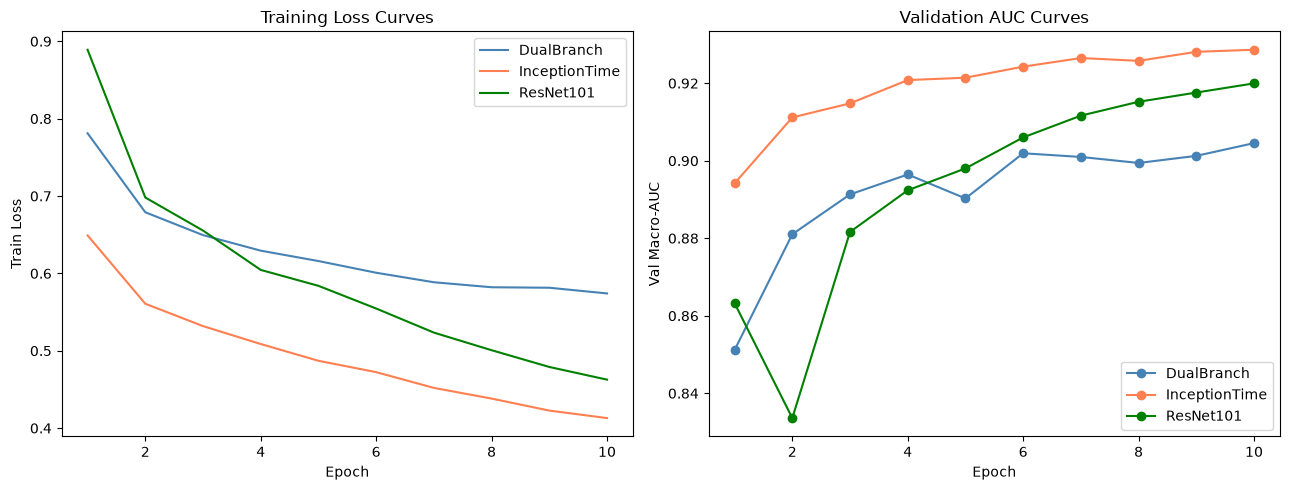

In [8]:
# ─── Individual TEST predictions ─────────────────────────────────────────────
preds1, tgts1 = predict_db(model1, db_test_loader,  DEVICE)
preds2, tgts2 = predict_sig(model2, sig_test_loader, DEVICE)
preds3, tgts3 = predict_sig(model3, sig_test_loader, DEVICE)

# All targets identical (same test set) — use tgts1 as ground truth
test_targets = tgts1

def model_report(preds, name):
    bin_preds = (preds >= 0.5).astype(int)
    auc   = macro_auc(test_targets, preds)
    acc   = accuracy_score(test_targets,  bin_preds)
    prec  = precision_score(test_targets, bin_preds, average='macro', zero_division=0)
    rec   = recall_score(test_targets,   bin_preds, average='macro', zero_division=0)
    f1    = f1_score(test_targets,       bin_preds, average='macro', zero_division=0)
    fmx   = fmax(test_targets, preds)
    auprc = macro_auprc(test_targets, preds)
    print(f'  {name:<25s}  ACC: {acc*100:.2f}%  AUC: {auc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}  '
          f'Fmax: {fmx:.4f}  AUPRC: {auprc:.4f}')
    return auc, acc, prec, rec, f1, fmx, auprc

print('='*90)
print('INDIVIDUAL MODEL TEST RESULTS')
print('='*90)
r1 = model_report(preds1, 'DualBranchECGNet')
r2 = model_report(preds2, 'InceptionTime1D')
r3 = model_report(preds3, 'ResNet1D-101')
print('='*90)

# ─── Training curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, EPOCHS + 1)
for losses, label, color in [
    (losses1, 'DualBranch', 'steelblue'),
    (losses2, 'InceptionTime', 'coral'),
    (losses3, 'ResNet101', 'green')
]:
    axes[0].plot(ep, losses, label=label, color=color)
for aucs, label, color in [
    (aucs1, 'DualBranch', 'steelblue'),
    (aucs2, 'InceptionTime', 'coral'),
    (aucs3, 'ResNet101', 'green')
]:
    axes[1].plot(ep, aucs, marker='o', label=label, color=color)

axes[0].set(xlabel='Epoch', ylabel='Train Loss', title='Training Loss Curves'); axes[0].legend()
axes[1].set(xlabel='Epoch', ylabel='Val Macro-AUC', title='Validation AUC Curves'); axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUTS_VAL / '04_ensemble_training_curves.png', dpi=200)
plt.show()

## 🎯 Module 8 — Soft Voting Ensemble + Final Benchmark

**Soft Voting** = simple average of all 3 models' sigmoid probabilities:
$$P_{ensemble}(x) = \frac{P_{DualBranch}(x) + P_{InceptionTime}(x) + P_{ResNet101}(x)}{3}$$

No additional training required. Zero extra parameters.


🎯 3-MODEL SOFT VOTING ENSEMBLE — FINAL TEST BENCHMARK
Accuracy  : 56.73%
Precision : 0.6804
Recall    : 0.8140
F1-Score  : 0.7399
Macro-AUC : 0.9243
  vs DualBranch alone : 54.41% Acc  AUC 0.8994
  vs InceptionTime    : 55.60% Acc  AUC 0.9280
  vs ResNet1D-101     : 52.73% Acc  AUC 0.9178
  Ensemble Gain (AUC) : +-0.37 pts over best single model


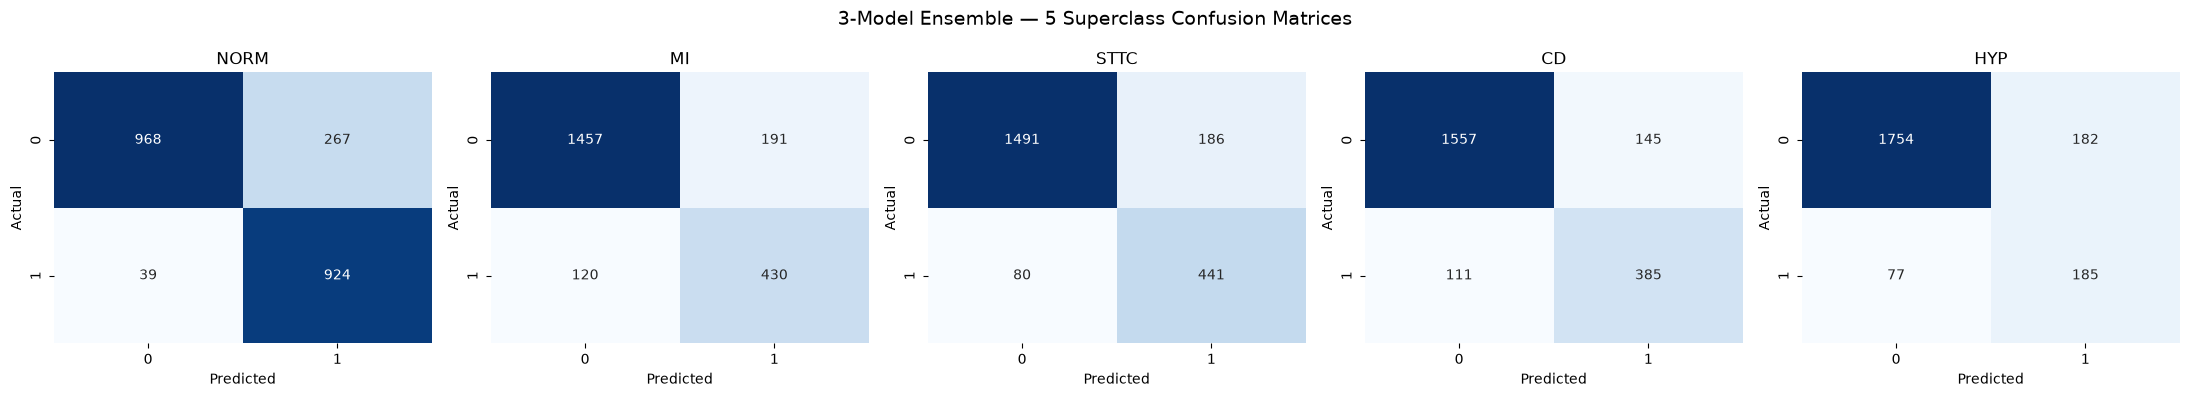

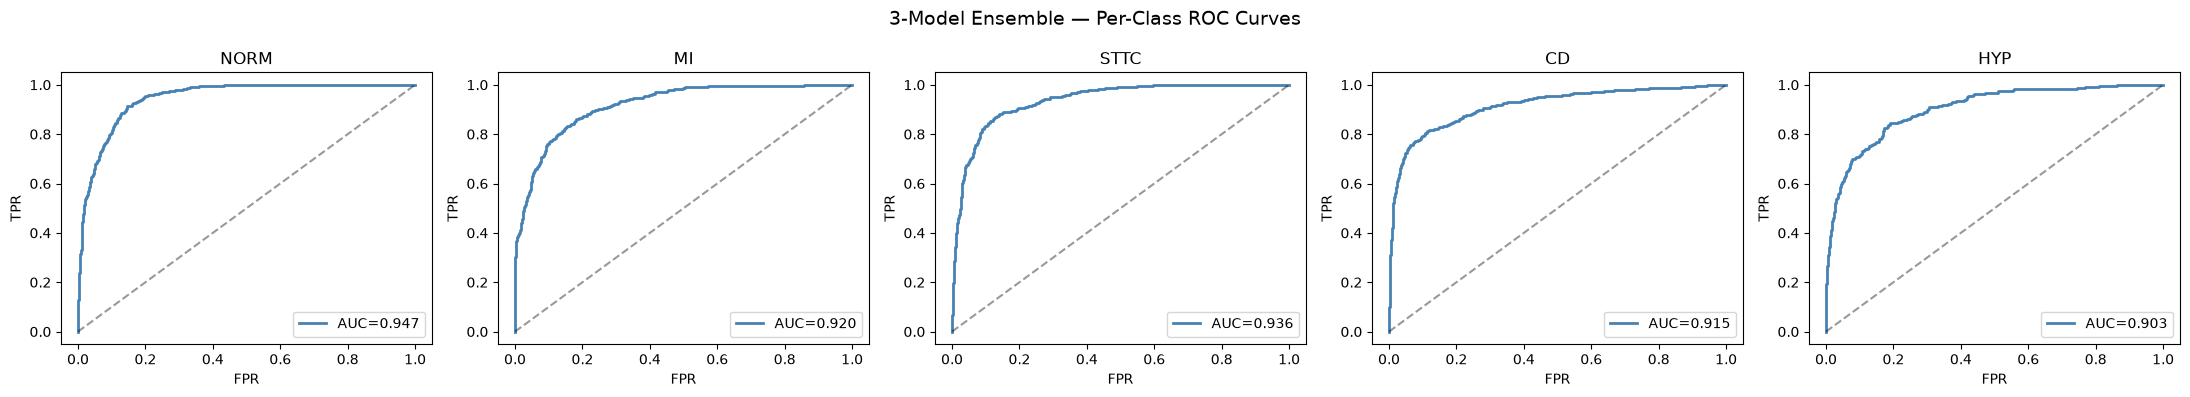

In [9]:
# ─── Soft voting: average probabilities ──────────────────────────────────────
ensemble_preds = (preds1 + preds2 + preds3) / 3.0
ensemble_bin   = (ensemble_preds >= 0.5).astype(int)

ens_auc   = macro_auc(test_targets, ensemble_preds)
ens_acc   = accuracy_score(test_targets,  ensemble_bin)
ens_prec  = precision_score(test_targets, ensemble_bin, average='macro', zero_division=0)
ens_rec   = recall_score(test_targets,   ensemble_bin, average='macro', zero_division=0)
ens_f1    = f1_score(test_targets,       ensemble_bin, average='macro', zero_division=0)
ens_fmax  = fmax(test_targets, ensemble_preds)
ens_auprc = macro_auprc(test_targets, ensemble_preds)

print('\n' + '='*65)
print('🎯 3-MODEL SOFT VOTING ENSEMBLE — FINAL TEST BENCHMARK')
print('='*65)
print(f'Accuracy    : {ens_acc*100:.2f}%')
print(f'Precision   : {ens_prec:.4f}')
print(f'Recall      : {ens_rec:.4f}')
print(f'F1-Score    : {ens_f1:.4f}')
print(f'Macro-AUC   : {ens_auc:.4f}')
print(f'Fmax        : {ens_fmax:.4f}')
print(f'Macro-AUPRC : {ens_auprc:.4f}')
print('='*65)
print(f'  vs DualBranch alone : {r1[1]*100:.2f}% Acc  AUC {r1[0]:.4f}  Fmax {r1[5]:.4f}  AUPRC {r1[6]:.4f}')
print(f'  vs InceptionTime    : {r2[1]*100:.2f}% Acc  AUC {r2[0]:.4f}  Fmax {r2[5]:.4f}  AUPRC {r2[6]:.4f}')
print(f'  vs ResNet1D-101     : {r3[1]*100:.2f}% Acc  AUC {r3[0]:.4f}  Fmax {r3[5]:.4f}  AUPRC {r3[6]:.4f}')
print(f'  Ensemble Gain (AUC) : +{(ens_auc - max(r1[0],r2[0],r3[0]))*100:.2f} pts over best single model')
print('='*65)

# ─── Per-class confusion matrices ────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, sc in enumerate(SUPERCLASSES):
    cm = confusion_matrix(test_targets[:, i], ensemble_bin[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(sc); axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
plt.suptitle('3-Model Ensemble — 5 Superclass Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUTS_VAL / '04_ensemble_confusion_matrices.png', dpi=300)
plt.show()

# ─── ROC curves (ensemble) ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, sc in enumerate(SUPERCLASSES):
    fpr, tpr, _ = roc_curve(test_targets[:, i], ensemble_preds[:, i])
    auc_sc = roc_auc_score(test_targets[:, i], ensemble_preds[:, i])
    axes[i].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={auc_sc:.3f}')
    axes[i].plot([0,1],[0,1],'k--',alpha=0.4)
    axes[i].set_title(sc); axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR'); axes[i].legend()
plt.suptitle('3-Model Ensemble — Per-Class ROC Curves', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUTS_VAL / '04_ensemble_roc_curves.png', dpi=300)
plt.show()

## 🩺 Module 9 — Age-Stratified Fairness Audit

In [10]:
df_audit = df_test.copy().reset_index(drop=True)
df_audit['pred_correct'] = (test_targets == ensemble_bin).all(axis=1)

age_groups = {
    '<40' :  df_audit[df_audit['age'] <  40],
    '40-65': df_audit[(df_audit['age'] >= 40) & (df_audit['age'] < 65)],
    '65-80': df_audit[(df_audit['age'] >= 65) & (df_audit['age'] < 80)],
    '80+':   df_audit[df_audit['age'] >= 80]
}

print('='*65)
print('📊 AGE-STRATIFIED SUBGROUP AUDIT — 3-Model Ensemble')
print('='*65)
for grp, df_g in age_groups.items():
    if len(df_g) > 0:
        print(f'  [{grp:>5s}]  n={len(df_g):4d}  |  Accuracy: {df_g["pred_correct"].mean()*100:.2f}%')
print('='*65)

📊 AGE-STRATIFIED SUBGROUP AUDIT — 3-Model Ensemble
  [  <40]  n= 284  |  Accuracy: 77.82%
  [40-65]  n= 866  |  Accuracy: 63.97%
  [65-80]  n= 708  |  Accuracy: 49.72%
  [  80+]  n= 340  |  Accuracy: 35.29%


## 📚 Module 10 — Literature Benchmark (metric-normalised)

**Only rows that use the same task framing and the same metric are comparable.** The PTB-XL 5-superclass problem is *multi-label*; the metric that every benchmark paper reports for it is **macro-AUC** (threshold-free). Atwa et al. 2025 instead report *single-label* multiclass accuracy (softmax + argmax, with the rarest sub-classes deleted to force class balance — confirmed from their own confusion matrices, where each row sums to that class's record count). That number answers an easier question and **cannot** be placed beside a multi-label macro-AUC.

| Study | Task framing | Metric | Value |
|---|---|---|---|
| Strodthoff et al. 2020 — best single (xresnet1d101) | multi-label | macro-AUC / Fmax | 0.928 / 0.823 |
| Strodthoff et al. 2020 — 6-model ensemble | multi-label | macro-AUC / Fmax | 0.929 / 0.825 |
| Gitau et al. 2025 — reproduced InceptionTime (fastai) | multi-label | macro-AUC | 0.929 |
| Gitau et al. 2025 — tuned InceptionTime (TF, grid-searched) | multi-label | macro-AUC | 0.922 |
| **This NB — InceptionTime1D alone (measured)** | multi-label | macro-AUC | **0.928** |
| **This NB — 3-model equal-weight ensemble (measured)** | multi-label | macro-AUC | **0.9243** |
| — | — | — | — |
| Atwa et al. 2025 — dual-branch CNN + demographics | **single-label** multiclass | accuracy | 0.7955 *(not comparable)* |
| This NB — 3-model ensemble, multi-label exact-match | multi-label subset acc | accuracy | 0.567 *(not comparable)* |

### Reading this table
- On the comparable metric (multi-label macro-AUC) this ensemble sits at **0.9243**, ~0.4–0.5 pt **below** the published single-model and ensemble benchmarks (0.928–0.929) — i.e. at parity, not ahead.
- The equal-weight ensemble (**0.9243**) scores **below its own best member**, InceptionTime1D (**0.928**), because DualBranchECGNet (macro-AUC ~0.899 on this run) drags the average down. Strodthoff et al. 2020 predict exactly this: “the best-performing single resnet or inception models always remain compatible with the ensemble result within error bars.”
- **Do not** present the accuracy rows next to the AUC rows in the slides without the “not comparable” caveat — it invites a reviewer to immediately spot the mismatch.

See `03_Optimized_Best_Model.ipynb` (AUC-weighted voting + per-class thresholds) and `papers/Whats_Needed_Next.md` for the fixes.